## Analysis of Fluidity Subduction model (Cerpa et al.)

Outstanding problem: robust trench identification

The main remaining challenge in this workflow is consistent, robust identification of the trench location through time in a dynamic subduction model.


Current approach

A three-phase spatial picker is implemented:

* Surface pressure provides a coarse trench candidate.
* Near-surface velocity identifies the kinematic plate boundary and search direction.
* Directional, windowed pressure search on the subducting plate side refines the trench pick.

This works well for individual timesteps but still requires careful tuning of window sizes and smoothing parameters, and can fail intermittently over long time series.



**Notes on overall dynamics of this system**

The working hypothesis is that both models undergo a clear, secular shift in the stress state at the trench, evolving from near‐neutral or weakly tensional conditions early in the run to increasingly compressional conditions at later times. This transition appears to reflect a systematic rebalancing of forces as the model evolves: plate velocities decrease and the effective plate length shortens, leading to a reduction in basal drag, while an initially strong pressure gradient in the asthenosphere that resists plate motion diminishes with time (and effectively vanishes in the weak asthenosphere case). That reduction in asthenospheric resistance is expressed as a progressive increase in the GPE-related term. With basal drag decreasing and GPE forces increasing, the ridge force and internal deformation forces appear unable to compensate fully, leaving compression at the trench as the only viable mechanism to close the force balance. The remaining task is to quantify these trends consistently through time—tracking basal drag, GPE, plate kinematics, and trench stress in a common framework—to demonstrate clearly how their combined evolution drives the observed transition to compressional trench stresses.

Establishign the average pressure gradient in the aspthenpshere between ridge and trench is trivial. You could ask does this decrease over time simply because of changes in plate length and velocity, or is an effect of lower mantle accumulatio.


In [1]:
#import pyvista as pv
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import h5py
from scipy.integrate import trapz, cumtrapz
from scipy.ndimage import gaussian_filter
import pyvista as pv
import warnings
import logging
from pathlib import Path

# 1) Redirect VTK C++ error output
pv.set_error_output_file(Path("/tmp/vtk_errors.log"))

# 2) Silence Python logging coming from VTK / PyVista
logging.getLogger("pyvista").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)

# 3) Silence the Python UserWarning layer
warnings.filterwarnings(
    "ignore",
    message="The VTK reader .*vtkXMLPUnstructuredGridReader.*"
)

plt.rcParams.update({
    "mathtext.fontset": "cm",  
    "font.family": "serif",     
})
import pyvista as pv
#import cmcrameri as cmc

In [2]:
#fbase = '/Users/DSAND/DATA/numerical_models/OUTPUTS/STD_RefModel/'
fbase = '/Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/'
modname = 'subduction_with_LM'


pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu')) 


In [3]:
len(pvtu_files)

41

In [4]:
i = 20
ff = pvtu_files[i]    #vtk filename
vtk_data = pv.read(ff);

## Helper functions

In [5]:
def get_field(name):
    f = interp[name].reshape((nx_pv, nz_pv), order="F")
    f[~valid] = np.nan
    return f.T        # (z, x)

def find_trench_x(
    x, z, p, vx,
    z_pick_m=5_000.0,          # use shallow depth for robustness (e.g., 5 km)
    window_km=300.0,           # search window half-width around p-based guess
    smooth_km=20.0,            # smooth vx along x before sign-change search
    require_opposite_sign=True # enforce left<0, right>0 (or vice versa)
):
    """
    Return trench x-location (m) using:
      1) coarse guess from min surface pressure
      2) refined pick from vx sign change near surface inside a window
    """

    # ---- pick depth index to evaluate (nearest to z_pick_m)
    iz = int(np.argmin(np.abs(z - z_pick_m)))
    vx1 = vx[iz, :].copy()
    p1  = p[0, :].copy()  # surface pressure for coarse guess

    # ---- coarse guess from pressure minimum (ignore NaNs)
    j0 = int(np.nanargmin(p1))
    x0 = x[j0]

    # ---- define search window around coarse guess
    W = window_km * 1000.0
    inwin = (x >= x0 - W) & (x <= x0 + W)

    xw = x[inwin]
    vxw = vx1[inwin]

    # ---- smooth vx along x (moving average)
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km * 1000.0) / dx))
    if k % 2 == 0:
        k += 1
    kernel = np.ones(k) / k
    vxws = np.convolve(vxw, kernel, mode="same")

    # ---- find sign-change locations (zero crossings)
    s = np.sign(vxws)
    s[s == 0] = np.nan  # treat exact zeros as missing for crossing detection
    # crossing where sign changes between adjacent samples
    cross = np.where(np.isfinite(s[:-1]) & np.isfinite(s[1:]) & (s[:-1] * s[1:] < 0))[0]

    if cross.size == 0:
        # fallback: minimum absolute vx in window (often close to shear zone)
        j = int(np.nanargmin(np.abs(vxws)))
        return xw[j], {"method": "min|vx|", "x0": x0, "iz": iz, "x_window": xw, "vx_window": vxw, "vx_smooth": vxws}

    # ---- choose the best crossing: closest to coarse guess
    # linearly interpolate zero crossing between xw[i], xw[i+1]
    x_cross = []
    for i in cross:
        x1, x2 = xw[i], xw[i+1]
        v1, v2 = vxws[i], vxws[i+1]
        # linear interpolation for v=0
        xc = x1 - v1 * (x2 - x1) / (v2 - v1)
        x_cross.append(xc)
    x_cross = np.array(x_cross)

    # optionally enforce direction: subducting plate rightwards, overriding leftwards
    if require_opposite_sign:
        keep = []
        for i, xc in zip(cross, x_cross):
            left = vxws[i]
            right = vxws[i+1]
            # accept either (- to +) or (+ to -); you can lock to one if you want
            if np.sign(left) != np.sign(right):
                keep.append(True)
            else:
                keep.append(False)
        keep = np.array(keep, dtype=bool)
        if keep.any():
            x_cross = x_cross[keep]

    # choose crossing closest to coarse pressure pick
    jbest = int(np.argmin(np.abs(x_cross - x0)))
    trench_x = float(x_cross[jbest])

    return trench_x, {"method": "vx_zero_cross", "x0": x0, "iz": iz, "x_cross": x_cross,
                      "x_window": xw, "vx_window": vxw, "vx_smooth": vxws}

In [6]:
# -------------------------------
# USER SETTINGS (meters)
# -------------------------------
dx = 1000.0                 # grid spacing (m)
z_max = 100000.0             # interpolate top z_max m
y_surface = 2900000.0       # VTK surface coordinate (m)

# -------------------------------
# READ VTK DATA
# -------------------------------
vtk_data = pv.read(ff)

vtk_data.point_data["p"]   = vtk_data["NormalSP::Pressure"]
vtk_data.point_data["txx"] = vtk_data["NormalSP::Stress"][:, 0]
vtk_data.point_data["tzz"] = vtk_data["NormalSP::Stress"][:, 4]
vtk_data.point_data["txz"] = vtk_data["NormalSP::Stress"][:, 1]
vtk_data.point_data["T"]   = vtk_data["NormalSP::Temperature"]

vel = vtk_data["NormalSP::Velocity"] / 3.17098e-10
vtk_data.point_data["vx"] = vel[:, 0]
vtk_data.point_data["vy"] = vel[:, 1]

# -------------------------------
# DEFINE REGULAR CELL-CENTRED GRID
# -------------------------------
x_min, x_max, _, _, _, _ = vtk_data.bounds

nx = int((x_max - x_min) / dx)
nz = int(z_max / dx)

x = x_min + (np.arange(nx) + 0.5) * dx      # meters
z = (np.arange(nz) + 0.5) * dx               # depth, meters

X, Z = np.meshgrid(x, z, indexing="xy")
Y = y_surface - Z                            # map depth → VTK y

grid = pv.StructuredGrid(
    X.T,
    Y.T,
    np.zeros_like(X.T)
)

# -------------------------------
# INTERPOLATE
# -------------------------------
interp = grid.sample(vtk_data)

nx_pv, nz_pv, _ = interp.dimensions
valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)



# -------------------------------
# FINAL ARRAYS (CANONICAL FORM)
# -------------------------------
p   = get_field("p")
txx = get_field("txx")
tzz = get_field("tzz")
txz = get_field("txz")
T   = get_field("T")
vx  = get_field("vx")
vz  = -get_field("vy")   # positive downward

# -------------------------------
# SANITY CHECKS
# -------------------------------
print("x (m):", x[0], "→", x[-1], "  nx =", len(x))
print("z (m):", z[0], "→", z[-1], "  nz =", len(z))
print("p.shape =", p.shape)

# field[z_index, x_index] lives at (x[x_index], z[z_index])

x (m): 500.0 → 7998500.0   nx = 7999
z (m): 500.0 → 99500.0   nz = 100
p.shape = (100, 7999)


In [7]:

surface_p = p[10, :]          # surface row
ploc = x[np.argmin(surface_p)]

In [8]:
tloc, info = find_trench_x(x, z, p, vx, z_pick_m=0, window_km=800, smooth_km=1)
print("trench_x (km):", tloc/1000, "method:", info["method"])

trench_x (km): 3321.4136418854137 method: vx_zero_cross


In [9]:
tindx = np.argmin(np.abs(x - tloc))
tindx

3321

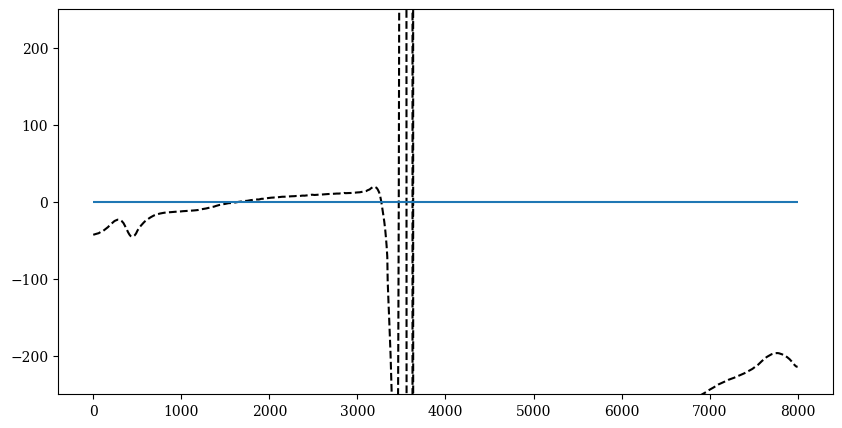

In [10]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot( x*1e-3, (p[-1,:] - p[-1,int(tindx/2)])/(3300*9.8), color= "k", ls = '--')

#ax.set_xlim(0, tloc*1e-3 + 200)
ax.set_ylim(-250, 250)
ax.hlines(0,0, 8000)

In [11]:
3300*9.8*200*100e3*1e-12

0.6468000000000002

## trench picking - another crack

In [12]:
import numpy as np

def moving_average_1d(y, k):
    if k <= 1:
        return y
    if k % 2 == 0:
        k += 1
    kernel = np.ones(k) / k
    return np.convolve(y, kernel, mode="same")

def first_local_minimum(y, min_prominence=0.0):
    """
    Return index of first local minimum in y.
    """
    for i in range(1, len(y) - 1):
        if y[i] < y[i-1] and y[i] < y[i+1]:
            if min_prominence <= 0:
                return i
            if (max(y[i-1], y[i+1]) - y[i]) >= min_prominence:
                return i
    return None



def pick_pressure_minimum_windowed(
    x, p_row, x_v,
    side="left",          # "left" means x < x_v ; "right" means x > x_v
    W_km=300.0,           # window width on that side
    expected_offset_km=50.0,   # optional bias (trench ~ x_v - 50 km)
    choose="closest_to_expected",  # or "deepest"
    allow_edge=False      # if False, reject minima at window edges
):
    W = W_km * 1000.0
    expected_offset = expected_offset_km * 1000.0

    if side == "left":
        mask = (x < x_v) & (x >= x_v - W)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + W)
        x_expected = x_v + expected_offset

    xw = x[mask]
    pw = p_row[mask]

    if xw.size < 5:
        raise RuntimeError("Step-3 window too small (need >=5 points).")

    # Drop NaNs explicitly (NaNs kill local-min tests)
    good = np.isfinite(pw)
    xw, pw = xw[good], pw[good]
    if xw.size < 5:
        raise RuntimeError("Too many NaNs in step-3 window.")

    # Identify strict local minima (no smoothing)
    # local min if p[i] < p[i-1] and p[i] < p[i+1]
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1   # shift because we tested 1:-1

    if idx.size == 0:
        # Fallback: choose minimum of pw, but it may be an edge point
        j = int(np.argmin(pw))
        return float(xw[j]), {
            "method": "fallback_argmin",
            "x_window": xw, "p_window": pw,
            "x_v": x_v
        }

    # Optionally reject minima too close to window edges
    if not allow_edge:
        idx = idx[(idx > 0) & (idx < len(pw)-1)]
        if idx.size == 0:
            j = int(np.argmin(pw))
            return float(xw[j]), {
                "method": "fallback_argmin_after_edge_reject",
                "x_window": xw, "p_window": pw,
                "x_v": x_v
            }

    # Choose which minimum to use
    if choose == "deepest":
        j = idx[np.argmin(pw[idx])]
        method = "localmin_deepest"
    else:
        # closest to expected x (e.g., x_v - 50 km)
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        method = "localmin_closest_to_expected"

    return float(xw[j]), {
        "method": method,
        "x_window": xw, "p_window": pw,
        "x_candidates": xw[idx],
        "p_candidates": pw[idx],
        "x_expected": x_expected,
        "x_v": x_v
    }

import numpy as np

def pick_trench_3step(
    x, z, p, vx,
    p_depth_m=0.0,            # depth for pressure row (0 -> z[0])
    vx_depth_m=5_000.0,       # depth for velocity diagnostics
    Wp1_km=800.0,             # coarse pressure window
    Wv_km=800.0,              # velocity window
    Wp3_km=300.0,             # FINAL pressure window (directional)
    expected_offset_km=50.0,  # expected trench offset from velocity transition
    smooth_km=20.0,           # smoothing ONLY for velocity
    subducting_side="left"    # "left" or "right" of velocity transition
):
    """
    Three-step non-stateful trench picker:
      1) coarse surface pressure minimum
      2) velocity sign-change (plate boundary)
      3) directional, windowed TRUE pressure minimum
    """

    # ---------------------------
    # Select depth rows
    # ---------------------------
    iz_p  = 0 if p_depth_m == 0.0 else int(np.argmin(np.abs(z - p_depth_m)))
    iz_vx = int(np.argmin(np.abs(z - vx_depth_m)))

    p_row  = p[iz_p, :].copy()
    vx_row = vx[iz_vx, :].copy()

    # ---------------------------
    # STEP 1: coarse pressure minimum
    # ---------------------------
    j0 = int(np.nanargmin(p_row))
    x_p0 = float(x[j0])

    # ---------------------------
    # STEP 2: velocity transition
    # ---------------------------
    # ---------------------------
    # STEP 2: velocity transition
    # ---------------------------
    Wv = Wv_km * 1000.0
    in_v = (x >= x_p0 - Wv) & (x <= x_p0 + Wv)
    
    x_vw  = x[in_v]
    vx_vw = vx_row[in_v]
    
    if x_vw.size < 5:
        raise RuntimeError("Velocity window too small")
    
    # smooth velocity ONLY
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km * 1000.0) / dx))
    if k % 2 == 0:
        k += 1
    kernel = np.ones(k) / k
    vx_s = np.convolve(vx_vw, kernel, mode="same")
    
    s = np.sign(vx_s)
    s[s == 0] = np.nan
    cross = np.where(
        np.isfinite(s[:-1]) &
        np.isfinite(s[1:]) &
        (s[:-1] * s[1:] < 0)
    )[0]
    
    if cross.size == 0:
        jv = int(np.nanargmin(np.abs(vx_s)))
        x_v = float(x_vw[jv])
        vx_method = "min|vx|"
    else:
        xc = []
        for i in cross:
            x1, x2 = x_vw[i], x_vw[i+1]
            v1, v2 = vx_s[i], vx_s[i+1]
            xc.append(x1 - v1 * (x2 - x1) / (v2 - v1))
        xc = np.array(xc)
    
        # 🔑 NEW RULE: pick leftmost velocity transition
        x_v = float(np.min(xc))
        vx_method = "zero_cross_leftmost"

    # ---------------------------
    # STEP 3: directional, windowed TRUE pressure minimum
    # ---------------------------
    Wp3 = Wp3_km * 1000.0
    expected_offset = expected_offset_km * 1000.0

    if subducting_side == "left":
        mask = (x < x_v) & (x >= x_v - Wp3)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + Wp3)
        x_expected = x_v + expected_offset

    xw = x[mask]
    pw = p_row[mask]

    if xw.size < 5:
        raise RuntimeError("Pressure window too small")

    # remove NaNs
    good = np.isfinite(pw)
    xw, pw = xw[good], pw[good]

    if xw.size < 5:
        raise RuntimeError("Too many NaNs in pressure window")

    # TRUE local minima (no smoothing)
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1

    if idx.size == 0:
        # explicit fallback
        j = int(np.argmin(pw))
        trench_x = float(xw[j])
        p_method = "fallback_global_min"
    else:
        # choose minimum closest to expected offset
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        trench_x = float(xw[j])
        p_method = "local_min_windowed"

    # ---------------------------
    # Diagnostics
    # ---------------------------
    info = {
        "x_p0": x_p0,
        "x_v": x_v,
        "trench_x": trench_x,
        "vx_method": vx_method,
        "p_method": p_method,
        "subducting_side": subducting_side,
        "depths_m": {
            "pressure": z[iz_p],
            "velocity": z[iz_vx]
        },
        "windows_km": {
            "Wp1": Wp1_km,
            "Wv": Wv_km,
            "Wp3": Wp3_km
        },
        "debug": {
            "x_vw": x_vw,
            "vx_s": vx_s,
            "xw": xw,
            "pw": pw,
            "x_candidates": xw[idx] if idx.size else None,
            "p_candidates": pw[idx] if idx.size else None
        }
    }

    return trench_x, info


In [13]:
tloc, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000,
    Wp1_km=1000,
    Wv_km=800,
    Wp3_km=800,          # <-- this is the key new control
    smooth_km=40,
    subducting_side="left"
)

print("Trench (km):", tloc / 1000)
print("Velocity anchor (km):", info["x_v"] / 1000)
print("Methods:", info["vx_method"], info["p_method"])

Trench (km): 3262.5
Velocity anchor (km): 3329.988702152328
Methods: zero_cross_leftmost local_min_windowed


In [14]:
#

(2762.5, 3762.5)

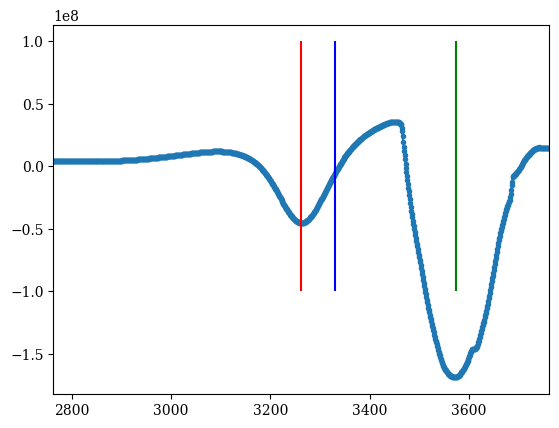

In [15]:
fig, ax = plt.subplots()

ax.plot(x*1e-3 , p[0,:], marker=".")

ax.vlines(tloc*1e-3, 1e8, -1e8, color='r')
ax.vlines(info["x_p0"]*1e-3, 1e8, -1e8, color='g')
ax.vlines(info["x_v"]*1e-3, 1e8, -1e8, color='b')

ax.set_xlim(tloc*1e-3 - 500, tloc*1e-3 + 500)


## Form the integrated traction quantities

In [16]:
from scipy.integrate import cumulative_trapezoid

In [17]:
Fd = np.trapz(txx- tzz, z, axis=0)   # shape (nx,)
GPE_ = -np.trapz((-p + tzz), z, axis=0)   # shape (nx,)
GPE = GPE_ - GPE_[tindx] + Fd[tindx]
V = np.trapz(-txz, z, axis=0)
dVdx  = np.gradient(V, x)

# basal shear stress (Pa)
tau_b = txz[-1, :]     # or -txz[-1, :] if you want opposite sign
# cumulative basal force per unit out-of-plane length (N/m)
FB_ = cumulative_trapezoid(tau_b, x, initial=0.0)
FB = FB_ - FB_[tindx]

(0.0, 3282.5)

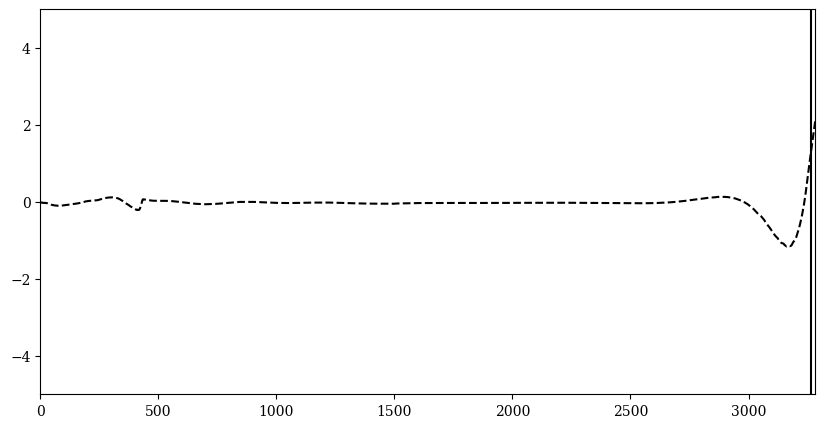

In [18]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot( x*1e-3, 1e-12*V, color= "k", ls = '--')
ax.vlines(tloc*1e-3, -10, 10, color= "k")

ax.set_ylim(-5, 5)
ax.set_xlim(0, tloc*1e-3 + 20)



(2762.5, 3462.5)

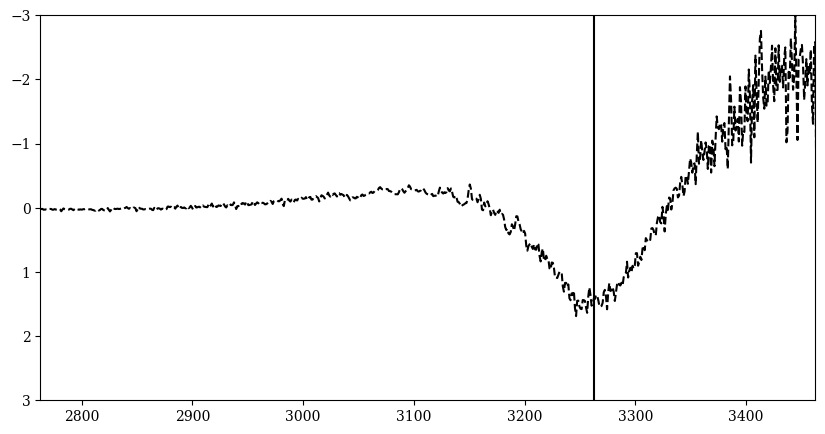

In [19]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot( x*1e-3, 1e-3*(dVdx/(3300*9.8)), color= "k", ls = '--')
ax.vlines(tloc*1e-3, -10, 10, color= "k")

ax.set_ylim(3, -3)
ax.set_xlim( tloc*1e-3 - 500, tloc*1e-3 + 200)


(-2.0, 2.0)

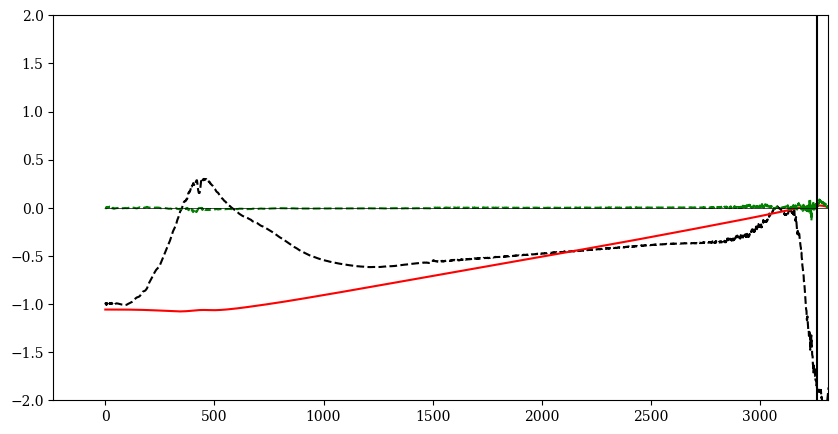

In [20]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot( x*1e-3, 1e-12*Fd, color= "k", ls = '--')
#ax.plot( x*1e-3, 1e-12*GPE, color= "b")
ax.plot( x*1e-3, 1e-12*FB, color= "r")

ax.plot( x*1e-3, 1e-12*(  GPE - Fd + FB), color= "g", ls = '--')



ax.vlines(tloc*1e-3, -2, 2, color= "k")
ax.hlines(0, 0, x[-1]*1e-3, color= "k", lw = 0.5)
ax.set_xlim(tloc*1e-3 - 3500, tloc*1e-3 + 50)
ax.set_ylim(-2, 2)



(-13.0, 4.0)

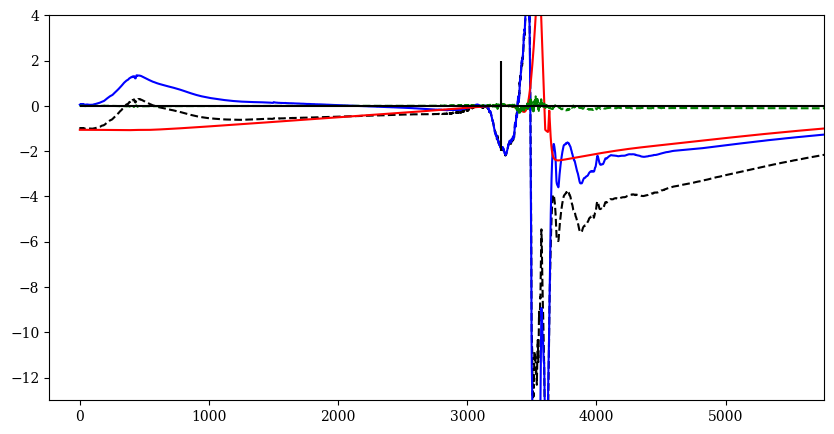

In [21]:
fig, ax = plt.subplots(figsize = (10, 5))

ax.plot( x*1e-3, 1e-12*Fd, color= "k", ls = '--')
ax.plot( x*1e-3, 1e-12*GPE, color= "b")

ax.plot( x*1e-3, 1e-12*FB, color= "r")
ax.plot( x*1e-3, 1e-12*(  GPE - Fd + FB), color= "g", ls = '--')



ax.vlines(tloc*1e-3, -2, 2, color= "k")
ax.hlines(0, 0, x[-1]*1e-3, color= "k")
ax.set_xlim(tloc*1e-3 - 3500, tloc*1e-3 + 2500)
ax.set_ylim(-13, 4)


(100.0, 0.0)

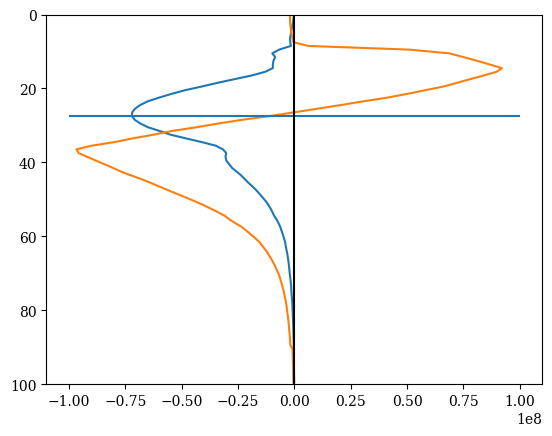

In [22]:
fig, ax = plt.subplots()

offset = 50
ax.plot(txz[:,tindx - offset], z*1e-3)
ax.plot(txx[:,tindx - offset], z*1e-3)
ax.hlines(1e-3*z[np.argmax(abs(txz[:,tindx - offset]))], -1e8, 1e8 )
ax.vlines(0, 0, 100, color = 'k')


ax.set_ylim( 100, 0)

In [23]:
np.argmax(abs(txz[:,tindx - offset]))

27

## Time evolution

In [24]:
import gc

Fd_tx = []

# constants (move outside loop)
dx = 1000.0
z_max = 100000.0
y_surface = 2900000.0

for i in range(1, len(pvtu_files)):
    ff = pvtu_files[i]

    # -------------------------------
    # READ VTK DATA
    # -------------------------------
    vtk_data = pv.read(ff)

    vtk_data.point_data["p"]   = vtk_data["NormalSP::Pressure"]
    vtk_data.point_data["txx"] = vtk_data["NormalSP::Stress"][:, 0]
    vtk_data.point_data["tzz"] = vtk_data["NormalSP::Stress"][:, 4]
    vtk_data.point_data["txz"] = vtk_data["NormalSP::Stress"][:, 1]

    vel = vtk_data["NormalSP::Velocity"] / 3.17098e-10
    vtk_data.point_data["vx"] = vel[:, 0]
    vtk_data.point_data["vy"] = vel[:, 1]

    # -------------------------------
    # GRID SETUP
    # -------------------------------
    x_min, x_max, _, _, _, _ = vtk_data.bounds

    nx = int((x_max - x_min) / dx)
    nz = int(z_max / dx)

    x = x_min + (np.arange(nx) + 0.5) * dx
    z = (np.arange(nz) + 0.5) * dx

    X, Z = np.meshgrid(x, z, indexing="xy")
    Y = y_surface - Z

    grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))

    # -------------------------------
    # INTERPOLATE
    # -------------------------------
    interp = grid.sample(vtk_data)

    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)

    # -------------------------------
    # EXTRACT FIELDS
    # -------------------------------
    p   = get_field("p")
    txx = get_field("txx")
    tzz = get_field("tzz")
    vx  = get_field("vx")

    # -------------------------------
    # TRENCH PICK
    # -------------------------------
    tloc, info = pick_trench_3step(
        x, z, p, vx,
        vx_depth_m=2000,
        Wp1_km=800,
        Wv_km=800,
        Wp3_km=500,          # <-- this is the key new control
        smooth_km=30,
        subducting_side="left"
    )

    tindx = np.argmin(np.abs(x - tloc))

    # -------------------------------
    # FORCE CALCULATION
    # -------------------------------
    Fd = np.trapz(txx - tzz, z, axis=0)
    Fd_tx.append(1e-12 * Fd[tindx])

    # -------------------------------
    # CLEANUP
    # -------------------------------
    del vtk_data, grid, interp
    del X, Y, Z, p, txx, tzz, vx, Fd

    if i % 5 == 0:
        gc.collect()


In [27]:
#Fd_tx_wal = np.copy(Fd_tx)
#Fd_tx_std = np.copy(Fd_tx)

In [32]:
#Fd_tx_std

Text(0.5, 0, 'time [Myr]')

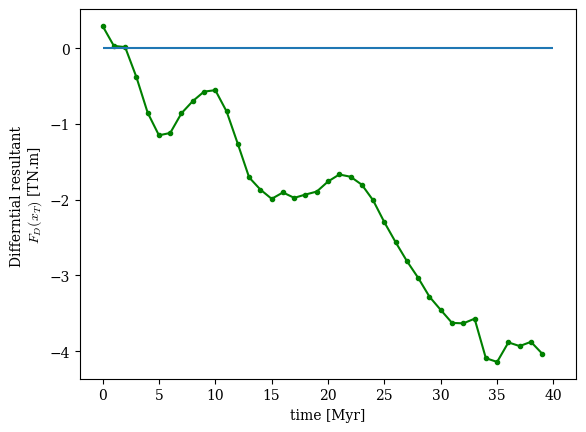

In [33]:
fig, ax = plt.subplots()
#ax.plot(Fd_tx_std, marker=".", c = "r")
ax.plot(Fd_tx, marker=".", c = "g")

ax.hlines(0, 0, 40)

ax.set_ylabel("Differntial resultant \n" + r"$F_D(x_T)$ [TN.m]")
ax.set_xlabel("time [Myr]")

In [34]:
#(500e6*100e3)*1e-12